<a href="https://colab.research.google.com/github/SUHANI-21/MachineLearningLab-2/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# DATA LOADING, CLEANING AND EDA
# Using Built-in Iris Dataset
# ============================================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. LOAD INBUILT IRIS DATASET
# ============================================

from sklearn.datasets import load_iris

iris = load_iris()

# Convert dataset into Pandas DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df['species'] = iris.target

# Convert target numbers to species names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print("Dataset loaded successfully!")

# ============================================
# 2. DISPLAY DATA
# ============================================

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

# ============================================
# 3. DATASET INFORMATION
# ============================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

# ============================================
# 4. CHECK MISSING VALUES
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

# ============================================
# 5. HANDLE MISSING VALUES
# ============================================

# Numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Fill missing categorical values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# ============================================
# 6. CHECK DUPLICATE VALUES
# ============================================

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)

# ============================================
# 7. SUMMARY STATISTICS
# ============================================

print("\nSummary Statistics:")
display(df.describe())

# ============================================
# 8. CATEGORICAL SUMMARY
# ============================================

print("\nSpecies Count:")
print(df['species'].value_counts())

# ============================================
# 9. MEAN, MEDIAN AND STANDARD DEVIATION
# ============================================

print("\nMean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nStandard Deviation:")
print(df[numeric_columns].std())



Dataset loaded successfully!

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Dataset Shape:
(150, 5)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Total Missing Values:
0

Missing values after cleaning:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Number of duplicate r

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Species Count:
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

Mean:
sepal length (cm)    5.843624
sepal width (cm)     3.059732
petal length (cm)    3.748993
petal width (cm)     1.194631
dtype: float64

Median:
sepal length (cm)    5.8
sepal width (cm)     3.0
petal length (cm)    4.3
petal width (cm)     1.3
dtype: float64

Standard Deviation:
sepal length (cm)    0.830851
sepal width (cm)     0.436342
petal length (cm)    1.767791
petal width (cm)     0.762622
dtype: float64


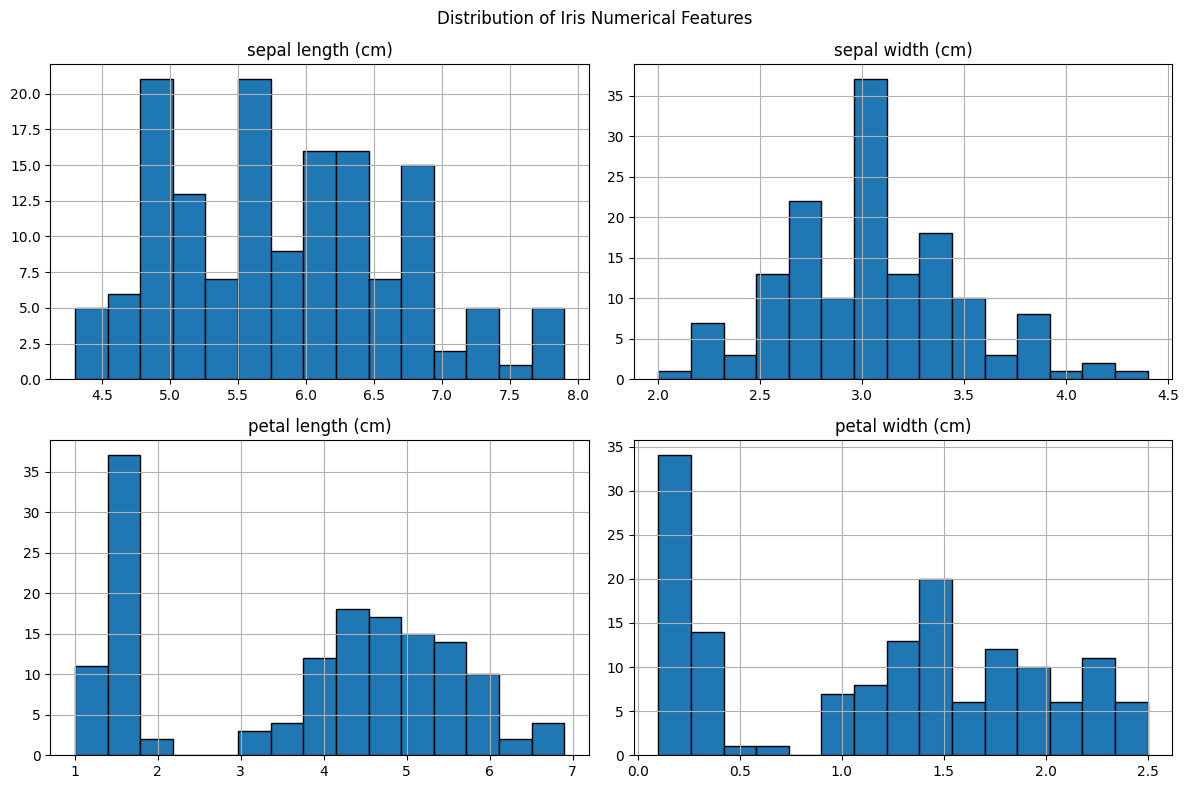

In [2]:
# ============================================
# 10. DISTRIBUTION PLOTS
# ============================================

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=15,
    edgecolor='black'
)

plt.suptitle("Distribution of Iris Numerical Features")
plt.tight_layout()
plt.show()


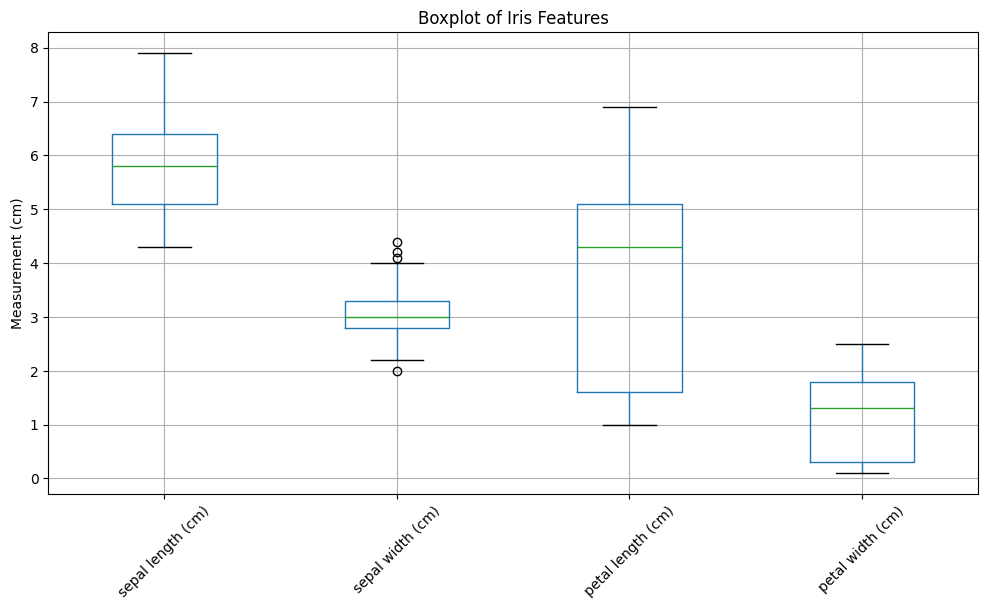


Correlation Matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.118129,0.873738,0.820620
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894
petal length (cm),0.873738,-0.426028,1.000000,0.962772
petal width (cm),0.820620,-0.362894,0.962772,1.000000


In [3]:
# ============================================
# 11. BOXPLOTS
# ============================================

plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Boxplot of Iris Features")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# ============================================
# 12. CORRELATION MATRIX
# ============================================

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
display(correlation)


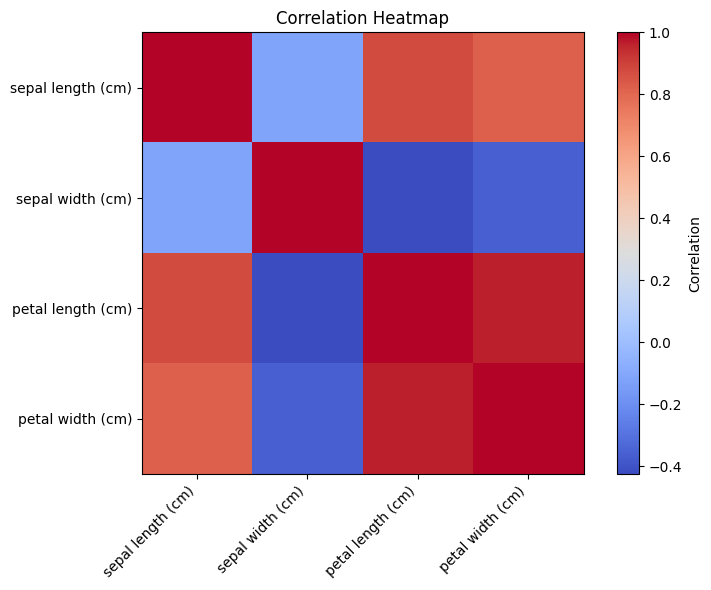

In [4]:
# ============================================
# 13. CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap='coolwarm',
    interpolation='none'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


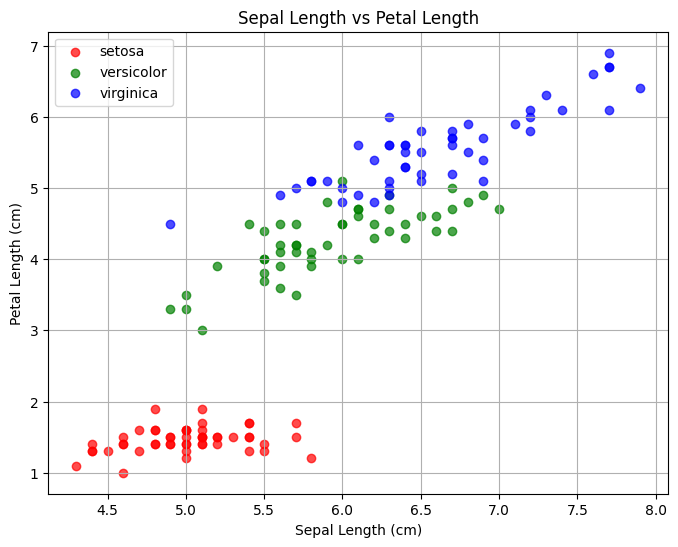

In [5]:
# ============================================
# 14. SCATTER PLOT
# ============================================

plt.figure(figsize=(8, 6))

colors = {
    'setosa': 'red',
    'versicolor': 'green',
    'virginica': 'blue'
}

for species in df['species'].unique():

    subset = df[df['species'] == species]

    plt.scatter(
        subset['sepal length (cm)'],
        subset['petal length (cm)'],
        label=species,
        color=colors[species],
        alpha=0.7
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length")
plt.legend()
plt.grid(True)

plt.show()


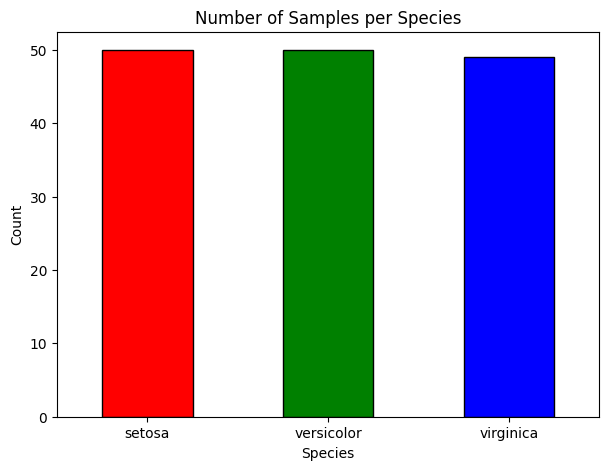

In [6]:
# ============================================
# 15. SPECIES DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

df['species'].value_counts().plot(
    kind='bar',
    color=['red', 'green', 'blue'],
    edgecolor='black'
)

plt.title("Number of Samples per Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()


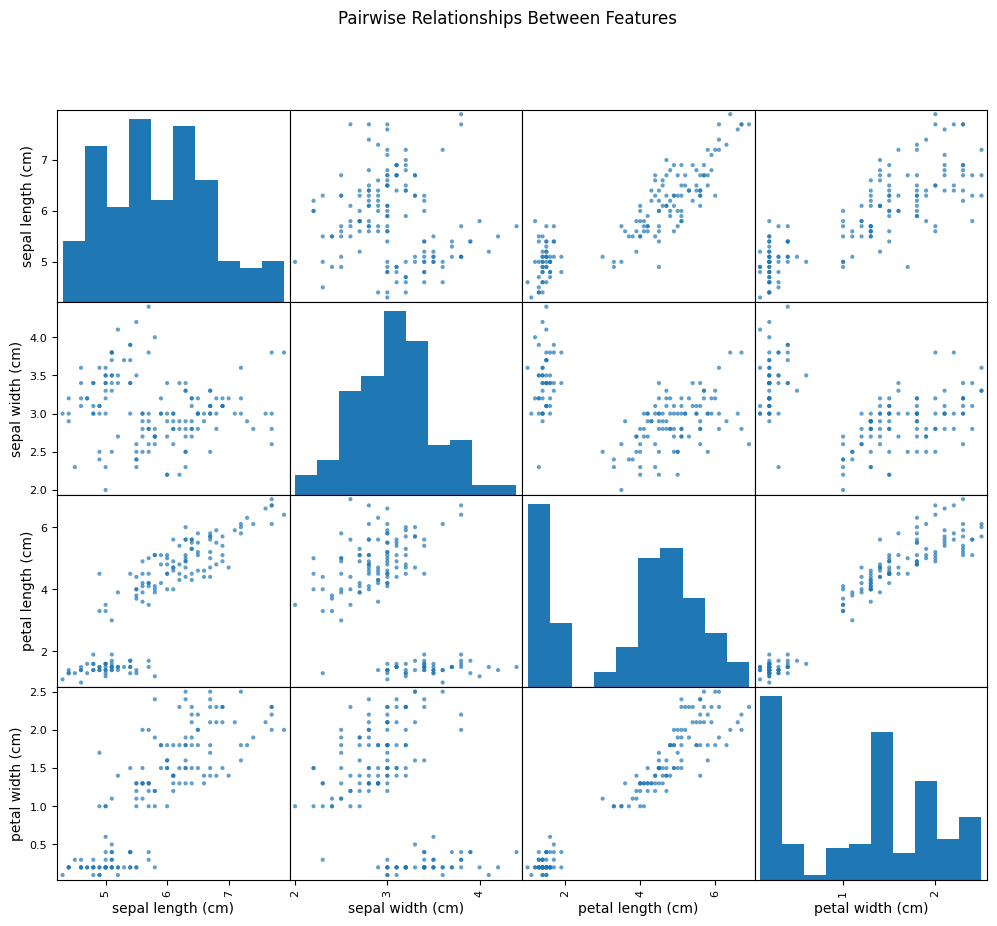

In [7]:
# ============================================
# 16. PAIRWISE SCATTER PLOTS
# ============================================

pd.plotting.scatter_matrix(
    df[numeric_columns],
    figsize=(12, 10),
    diagonal='hist',
    alpha=0.7
)

plt.suptitle("Pairwise Relationships Between Features")
plt.show()


In [8]:
# ============================================
# 17. FINAL DATASET
# ============================================

print("\nFinal Dataset:")
display(df.head())

print("\nFinal Shape:", df.shape)

print("\nFinal Missing Values:")
print(df.isnull().sum())


Final Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Final Shape: (149, 5)

Final Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [9]:
# ============================================
# 18. SAVE CLEANED DATASET
# ============================================

df.to_csv("cleaned_iris_dataset.csv", index=False)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!
